# MS4: Final Modeling and Deliverables

**CS 1090B Advanced Topics in Data Science**

_Group #2: Grant Solomon and Eric Ordonez, 3/12/2026_

In [1]:
import os
import sys
from pathlib import Path

# Mount Google Drive if running in Colab.
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_ROOT = Path('/content/drive/MyDrive/HES/CS_1090B/Project')
else:
    PROJECT_ROOT = Path('.')
os.chdir(PROJECT_ROOT)

## 1. Environment setup

`NCDENow` requires a pinned version of torchcde, and this project requires the same version to ensure full compatibility. But something has apparently since changed with this torchcde version, because getting the derivative attribute of cubic spline interpolations no longer works as instructed. To fix this, we internally apply a patch in our `NCDENow` wrapper that explicitly assigns the derivative.

In [2]:
!pip install -q python-dotenv fredapi torch torchcde==0.2.5 scikit-learn
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from src.data.series_catalog import CORE_SERIES, FREDQD_SERIES, GDP_TARGET
from src.data.fred_loader import get_api_key, load_fredmd, load_fredqd
from src.data.alfred_loader import (generate_nowcast_dates,
                                    load_or_build_ragged_edge)
from src.data.transforms import (apply_tcode, check_mid_sample_nans,
                                 transform_panel, trim_sample)
from src.models.dfm import (build_factor_panel, extract_factors_from_snapshot,
                            impute_ragged_edge)
from src.models.baselines import expanding_window_rf, expanding_window_ridge
from src.models.ncde import (align_gdp_to_nowcast_dates, expanding_window_ncde, 
                             fixed_split_ncde, _check_torchcde_compat)
from src.models.metrics import (build_comparison_table, compute_metrics,
                                crisis_window)
from src.models.plots import (plot_ncde_training_history, plot_predictions,
                              plot_terminal_loss)

This notebook was executed on a compute cluster using an NVIDIA L4 GPU (the printed output below may change depending on what is available).

In [3]:
# Use a GPU if available.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USING_GPU = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}')
if USING_GPU:
    print(f"  GPU:  {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU:  NVIDIA A10G
  VRAM: 23.7 GB


The cluster environment provides an earlier version of NumPy that makes pickling incompatible with the code that we wrote locally with a different NumPy version. This is a simple fix for that.

In [4]:
# NumPy on the cluster is 1.26.3.
import numpy.core.numeric
sys.modules['numpy._core.numeric'] = numpy.core.numeric

In [5]:
plt.style.use('seaborn-v0_8-white')

## 2. Configuration

A FRED API key is required to get the FRED-MD and FRED-QD series. You can request a key for free [here](https://fred.stlouisfed.org/docs/api/api_key.html), and it should go in a top level `.env` file like so:

```bash
# .env
export FRED_API_KEY="your_api_key"
```

We have provided cleaned versions of the data for our pipeline, so this notebook can still execute without querying and without an API key.

In [6]:
# Project directories.
DATA_DIR  = PROJECT_ROOT / 'data'
PLOTS_DIR = PROJECT_ROOT / 'plots'
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# Sample window.
SAMPLE_START = '2000-01-01'
SAMPLE_END   = '2024-12-01'

# DFM parameters.
N_FACTORS       = 6
LOOKBACK_MONTHS = 12
TRAIN_END       = '2018-12-01'

# NCDENow architecture parameters.
HIDDEN_SIZE        = 32
HIDDEN_HIDDEN_SIZE = 64
N_LAYERS           = 2
FE_TYPE            = 'FactorAnalysisEncoder'
CDE_TYPE           = 'MLPCDEFunc'
ODE_METHOD         = 'rk4'

# Training parameters.
N_EPOCHS     = 100
LR           = 5e-4
BATCH_SIZE   = 16
GRAD_CLIP    = 0.5
WEIGHT_DECAY = 1e-2
MIN_TRAIN_Q  = 20

# Set for reproducibility.
RANDOM_SEED = 109
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Load FRED API key.
API_KEY = get_api_key(env_path=PROJECT_ROOT / '.env', for_staff_evaluation=True)
if API_KEY is not None:
    print(f"FRED API key loaded: {'*' * 8}{API_KEY[-4:]}")

Executing for staff evaluation.
Raw data is already saved locally - no API key needed.


## 3. Data loading

We load 27 core FRED-MD series as the raw input data for this project.

In [7]:
# FRED-MD.
raw_fredmd = load_fredmd(
    data_dir=DATA_DIR,
    core_series=CORE_SERIES,
    api_key=API_KEY,
    verbose=True
)

FRED-MD loaded from cache: data/fredmd_raw_core.csv
  FRED-MD: shape=(377, 27)	1995-01-01 -> 2026-05-01


Only one FRED-QD series is actually needed as the target. We loaded two in the early phases of this project but ultimately needed one, so the second loading is an artifact from previous milestones.

In [8]:
# FRED-QD.
raw_fredqd = load_fredqd(
    data_dir=DATA_DIR,
    fredqd_series=FREDQD_SERIES,
    api_key=API_KEY,
    verbose=True
)

FRED-QD loaded from cache: data/fredqd_raw.csv
  FRED-QD: shape=(125, 2)	1995-01-01 -> 2026-01-01


## 4. Data transformation and EDA

First, we ensure that no data is missing and that it spans the sample window.

In [9]:
fredmd_transformed = transform_panel(raw_fredmd, core_series=CORE_SERIES)
fredmd_trimmed     = trim_sample(fredmd_transformed,
                                 start=SAMPLE_START, end=SAMPLE_END)

# Sanity check for missing data.
_ = check_mid_sample_nans(fredmd_trimmed)

✓ No unexpected mid-sample NaNs. Panel looks clean.


The target variable is real GDP growth. We convert quarterly level data (obtained from FRED-QD) to annualized quarter-on-quarter (QoQ) growth by taking the first difference of its logarithm and multiplying by 400.

In [10]:
gdp_raw         = raw_fredqd[GDP_TARGET]
gdp_transformed = apply_tcode(gdp_raw, tcode=5).dropna() * 400
gdp_trimmed     = gdp_transformed.loc[SAMPLE_START:SAMPLE_END]

print("GDP growth:\n"
      f"  n={len(gdp_trimmed)}\n"
      f"  mean={gdp_trimmed.mean():.4f}\n"
      f"  std={gdp_trimmed.std():.4f}\n"
      f"  min={gdp_trimmed.min():.4f}\n"
      f"  max={gdp_trimmed.max():.4f}")

GDP growth:
  n=100
  mean=2.1359
  std=5.0838
  min=-32.8173
  max=29.9030


US GDP has trended steadily upward since 2000. Of particular interest for economists is when the US enters a recession, defined as at least two consecutive quarters of negatve growth. That has happened twice since 2000: in the great financial crisis of 2008 and the COVID-19 pandemic beginning in 2020.

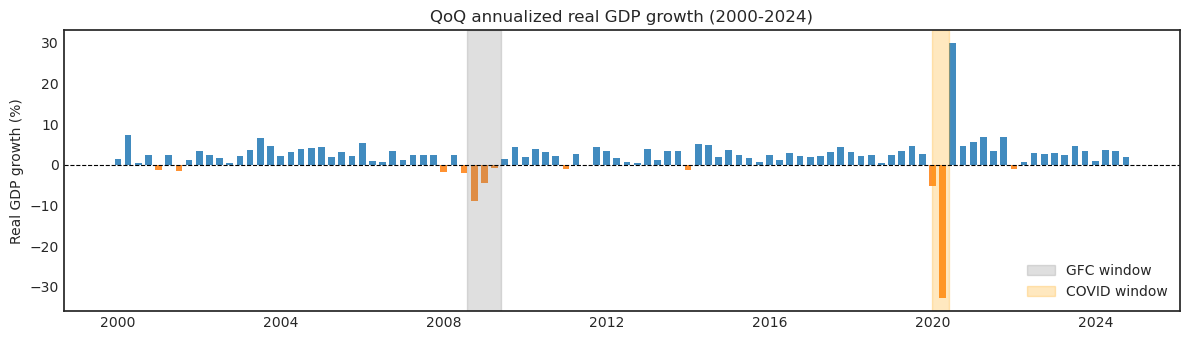

In [11]:
fig_gdp_growth, ax = plt.subplots(figsize=(12, 3.5))

ax.bar(gdp_trimmed.index, gdp_trimmed.values,
       color=np.where(gdp_trimmed.values >= 0, 'C0', 'C1'),
       width=60, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvspan(pd.Timestamp('2008-08-01'), pd.Timestamp('2009-06-01'),
           alpha=0.25, color='grey',label='GFC window')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-06-01'),
           alpha=0.25, color='orange', label='COVID window')
ax.set_title('QoQ annualized real GDP growth (2000-2024)', fontsize=12)
ax.set_ylabel('Real GDP growth (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='lower right')

fig_gdp_growth.tight_layout()
fig_gdp_growth.savefig(PLOTS_DIR / 'gdp_growth.png', dpi=150)
plt.show()

## 5. Ragged-edge data

Our nowcasting convention is to evaluate at the last day of the second month of each quarter.
For example, the nowcasting date for 2005 Q1 is 2005-02-28.
This is the most information-rich mid-quarter point: month-1 data for fast-releasing series
has arrived, and month-2 data is starting to trickle in.
This matches the "nowcast at month 2" convention used by Giannone et al. (2008).

In [12]:
nowcast_dates = generate_nowcast_dates(
    sample_start=SAMPLE_START,
    sample_end=SAMPLE_END
)
print(f"Nowcasting dates: {len(nowcast_dates)}")
print(f"Start: {nowcast_dates[0].date()}")
print(f"End:   {nowcast_dates[-1].date()}")

Nowcasting dates: 100
Start: 2000-02-29
End:   2024-11-30


The ragged-edge array is the core data structure for the model.
For each nowcast date, we query ALFRED for the real-time vintage of all 27 FRED-MD series, retaining only observations that had been officially released by that date.
The result is a tensor of shape `(T,L,N)`, or a list of `T=100` snapshots that each look at the last `L=12` observations up to and including the current nowcast date, for each of the `N=27` series.
This is fed into the ragged Dynamic Factor Model.

In [13]:
ragged = load_or_build_ragged_edge(
    data_dir=DATA_DIR,
    api_key=API_KEY,
    core_series=CORE_SERIES,
    nowcast_dates=nowcast_dates,
    lookback_months=LOOKBACK_MONTHS,
    fredmd_clean=raw_fredmd,
    sample_start=SAMPLE_START,
    sample_end=SAMPLE_END,
    force_rebuild=False,
    verbose=True,
)

snapshots    = ragged['snapshots']  # (T, L, N) raw untransformed
series_names = ragged['series_names']
T, L, N      = snapshots.shape
print(f"\nRagged array: T={T} dates  L={L} months  N={N} series")

Loading ragged-edge dataset from cache: data/alfred_ragged_edge.pkl
  Loaded: shape=(100, 12, 27)  (100 dates, 12 months, 27 series)

Ragged array: T=100 dates  L=12 months  N=27 series


The last months of each snapshot may contain NaNs for series that had not yet been released.
This can reflect genuine publication lag, i.e., series that do not get updated or published until months later.
It can also reflect series with poor ALFRED coverage.
The following heatmap visualizes which series are missing terminal-month observations and when.

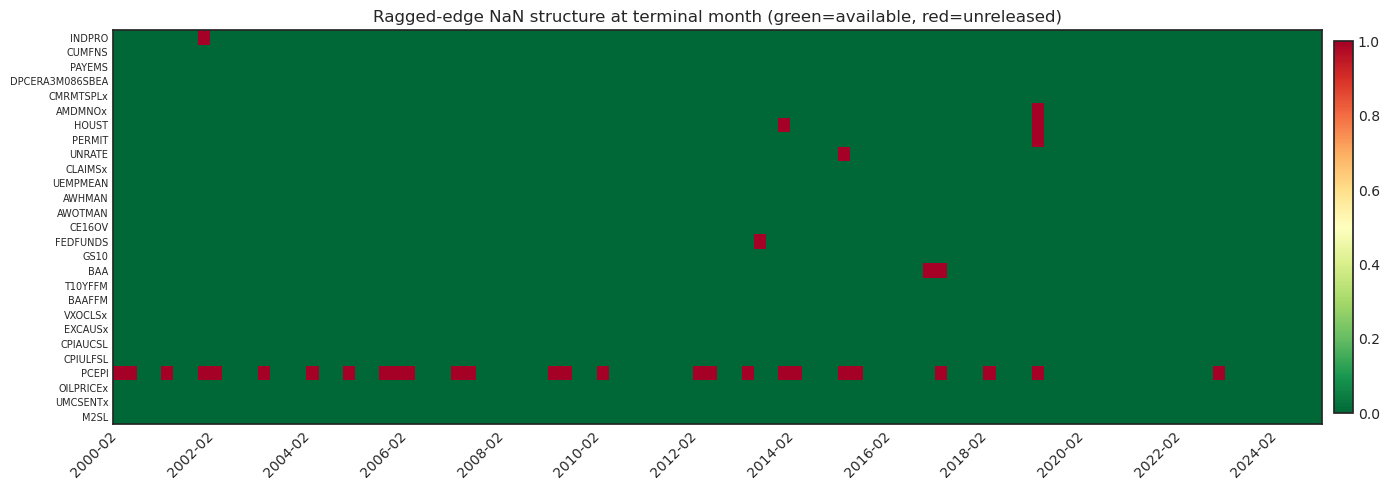

In [14]:
# NaN structure of which series are unreleased at the terminal month of each 
# snapshot.
terminal_nans = np.isnan(snapshots[:, -1, :])   # (T, N)

fig_heatmap, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(terminal_nans.T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(range(0, T, 8))
ax.set_xticklabels([d.strftime('%Y-%m') for d in nowcast_dates[::8]],
                   rotation=45, ha='right')
ax.set_yticks(range(N))
ax.set_yticklabels(series_names, fontsize=7)
ax.set_title('Ragged-edge NaN structure at terminal month '
             '(green=available, red=unreleased)')
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)

fig_heatmap.tight_layout()
fig_heatmap.savefig(PLOTS_DIR / 'ragged_edge_heatmap.png', dpi=150)
plt.show()

We transform each `(L,N)` snapshot with the appropriate FRED-MD transformation code for each series, then we forward-fill any remaining NaNs by rolling mean imputation.
The resulting tensor is the ragged-edge input for NCDENow.

In [15]:
# Transform and impute ragged-edge snapshots. Each (L, N) raw snapshot is 
# transformed with the FRED-MD tcodes, then NaNs are imputed via rolling means.
panels_ragged = np.zeros((T, L, N), dtype=np.float32)
for t_idx in range(T):
    snap_df      = pd.DataFrame(snapshots[t_idx], columns=series_names)
    snap_transf  = transform_panel(snap_df, core_series=CORE_SERIES)
    snap_imputed = impute_ragged_edge(snap_transf)
    panels_ragged[t_idx] = snap_imputed.values.astype(np.float32)

print(f"panels_ragged: {panels_ragged.shape}  "
      f"NaN remaining: {np.isnan(panels_ragged).sum()}")

/tmp/ipykernel_32562/1094992172.py:7: UserWarning: impute_ragged_edge: residual NaNs after imputation. Check for series that are entirely NaN in this snapshot.
  snap_imputed = impute_ragged_edge(snap_transf)
/tmp/ipykernel_32562/1094992172.py:7: UserWarning: impute_ragged_edge: residual NaNs after imputation. Check for series that are entirely NaN in this snapshot.
  snap_imputed = impute_ragged_edge(snap_transf)
/tmp/ipykernel_32562/1094992172.py:7: UserWarning: impute_ragged_edge: residual NaNs after imputation. Check for series that are entirely NaN in this snapshot.
  snap_imputed = impute_ragged_edge(snap_transf)
/tmp/ipykernel_32562/1094992172.py:7: UserWarning: impute_ragged_edge: residual NaNs after imputation. Check for series that are entirely NaN in this snapshot.
  snap_imputed = impute_ragged_edge(snap_transf)
/tmp/ipykernel_32562/1094992172.py:7: UserWarning: impute_ragged_edge: residual NaNs after imputation. Check for series that are entirely NaN in this snapshot.
  sn

panels_ragged: (100, 12, 27)  NaN remaining: 60


Note that there are still 60 NaNs after imputation, due to release dates that are truly missing.
This is an extremely neglible fraction (0.19%) of the total input, so we consider this an acceptable ragged-edge and fill the missing values with 0.

## 6. DFM factor extraction

The Dynamic Factor Model (DFM) compresses the 27 transformed FRED-MD series into a smaller number of latent variables that capture the dominant co-movement in the data.
We use PCA for this purpose.

In [16]:
dfm_result = build_factor_panel(
    fredmd_transformed=fredmd_trimmed,
    n_factors=N_FACTORS,
    train_end=TRAIN_END,
)

factors_clean_df = dfm_result['factors_df'] # (T_monthly, N_FACTORS)
loadings         = dfm_result['loadings']   # (N_FACTORS, n_series)
evr              = dfm_result['explained_variance_ratio']
scaler           = dfm_result['scaler']

print(f"Cumulative variance explained: {np.cumsum(evr).round(3)}")

PCA factor extraction: n_factors=6, (T,N)=(228, 27)
  Variance explained per factor: F1=18.8% F2=13.4% F3=10.5% F4=8.1% F5=7.0% F6=5.6%
  Cumulative:                    F1-1=18.8% F1-2=32.1% F1-3=42.6% F1-4=50.7% F1-5=57.7% F1-6=63.2%
Cumulative variance explained: [0.188 0.321 0.426 0.507 0.577 0.632]


The scree plot shows that six factors jointly explain 63.2% of the total variance, with the first factor alone explaining almost a fifth (18.8%).
This is consistent with McCracken and Ng's (2016) findings that FRED-MD series can reliably explain 60–70% of GDP with as few as four PCs.
Beyond six factors, the marginal gain drops below 6% per component.

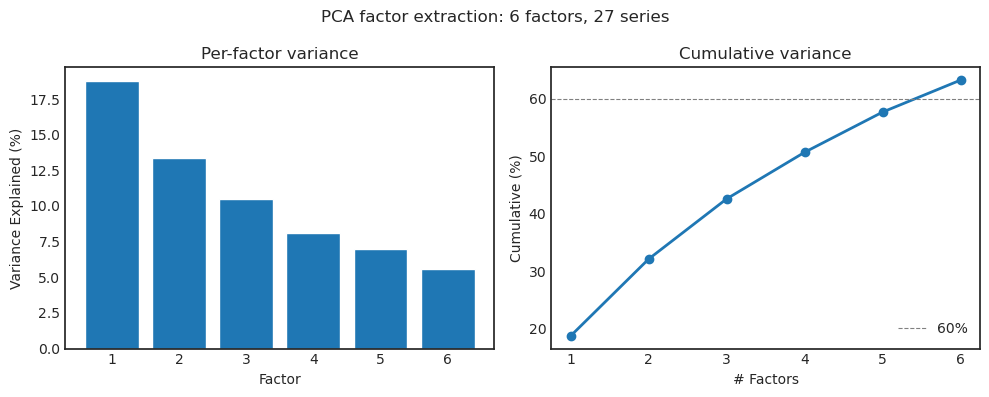

In [17]:
# Scree plot.
fig_scree, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(1, N_FACTORS+1), evr*100, color='C0', edgecolor='white')
axes[0].set(xlabel='Factor', ylabel='Variance Explained (%)',
            title='Per-factor variance', xticks=range(1, N_FACTORS+1))

axes[1].plot(range(1, N_FACTORS+1), np.cumsum(evr)*100,
             marker='o', color='C0', linewidth=2)
axes[1].axhline(60, color='grey', linestyle='--', linewidth=0.8, label='60%')
axes[1].set(xlabel='# Factors', ylabel='Cumulative (%)',
            title='Cumulative variance', xticks=range(1, N_FACTORS+1))
axes[1].legend()

fig_scree.suptitle(f'PCA factor extraction: {N_FACTORS} factors, {N} series',
                   fontsize=12)
fig_scree.tight_layout()
fig_scree.savefig(PLOTS_DIR / 'dfm_scree.png', dpi=150)
plt.show()

We construct a factor sequence as a latent space projection of the full, clean FRED-MD panel and align it to nowcast dates.

In [18]:
# Align clean factors to the nowcast dates.
factors_clean_aligned = np.zeros((T, N_FACTORS), dtype=np.float32)
for t_idx, t_now in enumerate(nowcast_dates):
    idx = factors_clean_df.index.asof(t_now)
    factors_clean_aligned[t_idx] = factors_clean_df.loc[idx].values

print(f"factors_clean_aligned: {factors_clean_aligned.shape}")

factors_clean_aligned: (100, 6)


Note that we do not do the same for the ragged panel.
We originally did but decided against using it for the final model.
Although a ragged factor panel is potentially more informative than the clean one, it suffers greatly in our construction because of outliers, and PCA is highly sensitive to outliers.
Our initial strategy was to clip the panel's standardized values at ±5 standard deviations, but this did not help with training stability or outcomes; we were seeing wildly unrealistic predicted GDP growth rates.

We decided to use the clean factor panel with the ragged model, which has the upside of it serving as an ablation baseline.
A more sophisticated DFM extraction process, or even our PCA procedure but enhanced with Kalman smoothing like that used by Lim et al. (2024), may avoid this problem.

## 7. Baseline models

We specify two baseline models against which to benchmark our NCDENow performance:

1. Ridge regression
2. Random forest regressor

Each model regresses GDP growth on the most recently available observation of each (transformed) FRED-MD series as of the nowcast date. 
That makes this a flat cross-section with no long-term temporal structure; it simply looks at how the previous value relates to the next value.

In [19]:
X_baselines = np.zeros((T, N), dtype=np.float32)
for t_idx, t_now in enumerate(nowcast_dates):
    idx = fredmd_trimmed.index.asof(t_now)
    X_baselines[t_idx] = fredmd_trimmed.loc[idx].values

print(f"X_baselines: {X_baselines.shape}  NaN: {np.isnan(X_baselines).sum()}")

X_baselines: (100, 27)  NaN: 0


In [20]:
gdp_series_df = raw_fredqd.copy()
gdp_series_df[GDP_TARGET] = gdp_transformed
gdp_aligned = align_gdp_to_nowcast_dates(
    gdp_series_df,
    nowcast_dates,
    gdp_col=GDP_TARGET
)

We introduce two training and evaluation methods to be applied to all models:

1. An **expanding window** where the model is retrained at every nowcast step, then predicts the next step as if it were frozen in time and forecasting the future.
2. A traditional **fixed split** into training and test windows.

The first method is a more realistic depiction of nowcasting and how we want our models to work, but it comes with caveats that we discuss in our report.
The second method is the method used by Lim et al. (2024) and again comes with its own caveats, which we discuss.

In [21]:
FIXED_SPLIT_DATE  = pd.Timestamp('2019-02-28')
FIXED_TRAIN_END_IDX = next(
    i for i, d in enumerate(nowcast_dates)
    if d >= FIXED_SPLIT_DATE
)

### 7.1 Ridge regression

Ridge regression is a common choice in GDP forecasting because $L_2$ regularization is effective at dealing with the multicollinearity common between economic indicators used to predict GDP.
In our case, it is also useful because we have 27 predictors for 1 outcome, so there is serious risk of overfitting. 

We fit the ridge regression model via cross-validation.
In expanding window evaluation, a new cross-validated model is fit from scratch at each step and its performance averaged over the entire sample.
In fixed split evaluation, one model is trained and evaluated on all data up to the split date, then its performance is measured on the test dates.

In [22]:
results_ridge_csv = DATA_DIR / 'results_ridge.csv'
if results_ridge_csv.exists():
    print("Loading Ridge (expanding window)...")
    results_ridge = pd.read_csv(
        results_ridge_csv,
        parse_dates=['nowcast_date']
    )
else:
    print("Running Ridge (expanding window)...")
    results_ridge = expanding_window_ridge(
        X=X_baselines,
        y=gdp_aligned,
        nowcast_dates=nowcast_dates,
        min_train_quarters=MIN_TRAIN_Q,
        verbose=False
    )
    results_ridge.to_csv(results_ridge_csv, index=False)

m = compute_metrics(results_ridge, 'Ridge (expanding window)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading Ridge (expanding window)...
  n=80  RMSE=7.6775  MAE=2.5735  MDA=0.8750


In [23]:
results_ridge_fixed_csv = DATA_DIR / 'results_ridge_fixed.csv'
if results_ridge_fixed_csv.exists():
    print("Loading Ridge (fixed split)...")
    results_ridge_fixed = pd.read_csv(
        results_ridge_fixed_csv,
        parse_dates=['nowcast_date']
    )
else:
    print("Running Ridge (fixed split)...")
    results_ridge_fixed = expanding_window_ridge(
        X=X_baselines,
        y=gdp_aligned,
        nowcast_dates=nowcast_dates,
        min_train_quarters=FIXED_TRAIN_END_IDX,
        verbose=False
    )
    results_ridge_fixed.to_csv(results_ridge_fixed_csv, index=False)

m = compute_metrics(results_ridge_fixed, 'Ridge (fixed split)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading Ridge (fixed split)...
  n=24  RMSE=13.7528  MAE=5.4976  MDA=0.8333


### 7.2 Random Forest

A Random Forest seeks to mitigate overfitting for the same reason we choose ridge regression model: to prevent overfitting on small expanding-window samples.
Another purpose is to serve as a benchmark for a nonlinear model that can learn to capture interaction effects between the predictors, which is something we cannot do with a regression model without specifying it a priori.

The training hyperparameters were chosen in Milestone 3.

In [24]:
results_rf_csv = DATA_DIR / 'results_rf.csv'
if results_rf_csv.exists():
    print("Loading Random Forest (expanding window)...")
    results_rf = pd.read_csv(results_rf_csv, parse_dates=['nowcast_date'])
else:
    print("Running Random Forest (expanding window)...")
    results_rf = expanding_window_rf(
        X=X_baselines,
        y=gdp_aligned,
        nowcast_dates=nowcast_dates,
        min_train_quarters=MIN_TRAIN_Q,
        verbose=False
    )
    results_rf.to_csv(results_rf_csv, index=False)
    
m = compute_metrics(results_rf, 'RF (expanding window)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading Random Forest (expanding window)...
  n=80  RMSE=5.6641  MAE=2.3182  MDA=0.8750


In [25]:
results_rf_fixed_csv = DATA_DIR / 'results_rf_fixed.csv'
if results_rf_fixed_csv.exists():
    print("Loading Random Forest (fixed split)...")
    results_rf_fixed = pd.read_csv(
        results_rf_fixed_csv,
        parse_dates=['nowcast_date']
    )
else:
    print("Running Random Forest (fixed split)...")
    results_rf_fixed = expanding_window_rf(
        X=X_baselines,
        y=gdp_aligned,
        nowcast_dates=nowcast_dates,
        min_train_quarters=FIXED_TRAIN_END_IDX,
        verbose=False
    )
    results_rf_fixed.to_csv(results_rf_fixed_csv, index=False)

m = compute_metrics(results_rf_fixed, 'RF (fixed split)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading Random Forest (fixed split)...
  n=24  RMSE=9.8838  MAE=4.4412  MDA=0.8333


## 8. NCDENow

The NCDENow model is the main model of this project.
It consists of three components operating in sequence:

1. **Input encoding:** At the snapshot for each nowcast date, the `(L=12, N=27)` panel is projected through a factor analysis encoder that maps each monthly observation to a dense embedding.
2. **NCDE hidden state:** A Neural Controlled Differential Equation integrates the continuous input path to produce a hidden state at the terminal time. The input path is interpolated from the discrete monthly observations via cubic splines.
3. **Regression head:** The hidden state is combined with the DFM factor vector to produce a scaled GDP growth prediction.

We train with the Adam optimizer at learning rate of `5e-4`, gradient clipping set to `0.5`, and weight decay of `0.01`. We use the 4th-order Runge-Kutta (`r4k`) ODE solver for the NCDE component.

The hidden state dimensions are 32 and 64, which are each half those used by Lim et al. (2024).
This downscaling is in the interest of training time and our available resources, but we do add a second layer to the encoder, whereas the papers uses only one.

The learning rate and weight decay were settled upon after a small grid search that revealed them to be the best combination for training loss stability.

In [26]:
# Check torchcde compatibility.
_check_torchcde_compat()

torchcde 0.2.5: public derivative() detected, patch will be applied on first model import.


In [27]:
TRAIN_END_DATE = pd.Timestamp('2018-11-30')
N_EPOCHS_FIXED = 200

### 8.1 Clean model

The clean model uses the transformed FRED-MD panel with no ragged edges.
The dates of all observations align as if they were simulateounsly released at month-end.
This is an ablation baseline to determine if the NCDE architecture itself adds any value over the flat-feature baseline models, before we consider adding the ragged-edge complication. 

In [28]:
# Build clean panel array: (T, LOOKBACK_MONTHS, N).
panels_clean = np.zeros((T, LOOKBACK_MONTHS, N), dtype=np.float32)
for t_idx, t_now in enumerate(nowcast_dates):
    obs_start = (t_now - pd.DateOffset(months=LOOKBACK_MONTHS-1)).replace(day=1)
    window = fredmd_trimmed.loc[obs_start:t_now].values.astype(np.float32)
    if len(window) >= LOOKBACK_MONTHS:
        panels_clean[t_idx] = window[-LOOKBACK_MONTHS:]
    else:
        panels_clean[t_idx, -len(window):] = window

print(f"panels_clean: {panels_clean.shape}  "
      f"NaN: {np.isnan(panels_clean).sum()}")

panels_clean: (100, 12, 27)  NaN: 0


In expanding window evaluation, the model is re-trained at every quarter for 100 epochs per step.
In fixed split evaluation, a single model is trained through 2018 Q4 for 200 epochs, to allow a more thorough convergence.

In [29]:
results_ncde_clean_csv = DATA_DIR / 'results_ncde_clean.csv'
history_ncde_clean_csv = DATA_DIR / 'history_ncde_clean.csv'
if results_ncde_clean_csv.exists() and history_ncde_clean_csv.exists():
    print("Loading NCDENow (clean, expanding window...")
    results_ncde_clean = pd.read_csv(
        results_ncde_clean_csv,
        parse_dates=['nowcast_date']
    )
    history_ncde_clean = pd.read_csv(
        history_ncde_clean_csv,
        parse_dates=['nowcast_date']
    )
else:
    print(f"Training NCDENow (clean, expanding window) on {DEVICE}...")
    print(f"{T - MIN_TRAIN_Q} steps, {N_EPOCHS} epochs...")
    result_clean = expanding_window_ncde(
        panels=panels_clean,
        factors=factors_clean_aligned,
        gdp_growth=gdp_aligned,
        nowcast_dates=nowcast_dates,
        epochs=N_EPOCHS,
        lr=LR,
        grad_clip=GRAD_CLIP,
        weight_decay=WEIGHT_DECAY,
        checkpoint_dir=DATA_DIR / 'checkpoints',
        checkpoint_label='ncde_clean',
        device=DEVICE
    )
    # Save results.
    results_ncde_clean  = result_clean.predictions
    history_ncde_clean  = result_clean.history
    results_ncde_clean.to_csv(results_ncde_clean_csv, index=False)
    history_ncde_clean.to_csv(history_ncde_clean_csv, index=False)

m = compute_metrics(results_ncde_clean, 'NCDENow (clean, expanding window)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading NCDENow (clean, expanding window...
  n=80  RMSE=8.7963  MAE=4.4247  MDA=0.8125


In [30]:
results_ncde_clean_fixed_csv = DATA_DIR / 'results_ncde_clean_fixed.csv'
history_ncde_clean_fixed_csv = DATA_DIR / 'history_ncde_clean_fixed.csv'
if results_ncde_clean_fixed_csv.exists() and history_ncde_clean_fixed_csv.exists():
    print("Loading NCDENow (clean, fixed split...")
    results_ncde_clean_fixed = pd.read_csv(
        results_ncde_clean_fixed_csv,
        parse_dates=['nowcast_date']
    )
    history_ncde_clean_fixed = pd.read_csv(
        history_ncde_clean_fixed_csv,
        parse_dates=['nowcast_date']
    )
else:
    print(f"Training NCDENow (clean, fixed split) on {DEVICE}...")
    result_clean_fixed = fixed_split_ncde(
        panels=panels_clean,
        factors=factors_clean_aligned,
        gdp_growth=gdp_aligned,
        nowcast_dates=nowcast_dates,
        train_end_date=TRAIN_END_DATE,
        epochs=N_EPOCHS_FIXED,
        lr=LR,
        grad_clip=GRAD_CLIP,
        weight_decay=WEIGHT_DECAY,
        checkpoint_dir=DATA_DIR / 'checkpoints',
        checkpoint_label='ncde_clean_fixed',
        device=DEVICE
    )
    # Save results.
    results_ncde_clean_fixed = result_clean_fixed.predictions
    history_ncde_clean_fixed = result_clean_fixed.history
    results_ncde_clean_fixed.to_csv(results_ncde_clean_fixed_csv, index=False)
    history_ncde_clean_fixed.to_csv(history_ncde_clean_fixed_csv, index=False)

m = compute_metrics(results_ncde_clean_fixed, 'NCDENow (clean, fixed split)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading NCDENow (clean, fixed split...
  n=24  RMSE=8.1414  MAE=4.2418  MDA=0.9167


### 8.2. Ragged-edge model

The ragged-edge model uses the ragged panel of ALFRED snapshots, but it is otherwise trained identically to the clean model.
We also identically use the clean factors sequence for the aforementioned reasons.
Conveniently, this further underscores the clean model as an ablation baseline because the effect of the ragged edge enters only through the real-time path data and cannot be attributed to the factor computation.

We do clip the panel to `(-20, 20)` for training stability.

In [31]:
# Fill NaNs and clip.
panels_ragged_safe = np.where(np.isnan(panels_ragged), 0.0, panels_ragged)
assert not np.isnan(panels_ragged_safe).any(), "Still NaN after fill"
assert not np.isinf(panels_ragged_safe).any(), "Inf values present"
panels_ragged_safe = np.clip(panels_ragged_safe, -20, 20).astype(np.float32)
print(f"panels_ragged_safe:  max abs={np.abs(panels_ragged_safe).max():.4f}  "
      f"NaN={np.isnan(panels_ragged_safe).sum()}  "
      f"Inf={np.isinf(panels_ragged_safe).sum()}")

panels_ragged_safe:  max abs=20.0000  NaN=0  Inf=0


In [32]:
results_ncde_ragged_csv = DATA_DIR / 'results_ncde_ragged.csv'
history_ncde_ragged_csv = DATA_DIR / 'history_ncde_ragged.csv'
if results_ncde_ragged_csv.exists() and history_ncde_ragged_csv.exists():
    print("Loading NCDENow (ragged, expanding window...")
    results_ncde_ragged = pd.read_csv(
        results_ncde_ragged_csv,
        parse_dates=['nowcast_date']
    )
    history_ncde_ragged = pd.read_csv(
        history_ncde_ragged_csv,
        parse_dates=['nowcast_date']
    )
else:
    print(f"Training NCDENow (ragged, expanding window) on {DEVICE}...")
    print(f"{T - MIN_TRAIN_Q} steps, {N_EPOCHS} epochs...")
    result_ragged = expanding_window_ncde(
        panels=panels_ragged_safe,
        factors=factors_clean_aligned,
        gdp_growth=gdp_aligned,
        nowcast_dates=nowcast_dates,
        epochs=N_EPOCHS,
        lr=LR,
        grad_clip=GRAD_CLIP,
        weight_decay=WEIGHT_DECAY,
        checkpoint_dir=DATA_DIR / 'checkpoints',
        checkpoint_label='ncde_ragged',
        device=DEVICE
    )
    # Save results.
    results_ncde_ragged  = result_ragged.predictions
    history_ncde_ragged  = result_ragged.history
    results_ncde_ragged.to_csv(results_ncde_ragged_csv, index=False)
    history_ncde_ragged.to_csv(history_ncde_ragged_csv, index=False)

m = compute_metrics(results_ncde_ragged, 'NCDENow (ragged, expanding window)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading NCDENow (ragged, expanding window...
  n=80  RMSE=6.5954  MAE=3.5692  MDA=0.7250


In [33]:
results_ncde_ragged_fixed_csv = DATA_DIR / 'results_ncde_ragged_fixed.csv'
history_ncde_ragged_fixed_csv = DATA_DIR / 'history_ncde_ragged_fixed.csv'
if results_ncde_ragged_fixed_csv.exists() and history_ncde_ragged_fixed_csv.exists():
    print("Loading NCDENow (ragged, fixed split)...")
    results_ncde_ragged_fixed = pd.read_csv(
        results_ncde_ragged_fixed_csv,
        parse_dates=['nowcast_date']
    )
    history_ncde_ragged_fixed = pd.read_csv(
        history_ncde_ragged_fixed_csv,
        parse_dates=['nowcast_date']
    )
else:
    print(f"Training NCDENow (ragged, fixed split) on {DEVICE}...")
    result_ragged_fixed = fixed_split_ncde(
        panels=panels_ragged,
        factors=factors_clean_aligned,
        gdp_growth=gdp_aligned,
        nowcast_dates=nowcast_dates,
        train_end_date=TRAIN_END_DATE,
        epochs=N_EPOCHS_FIXED,
        lr=LR,
        grad_clip=GRAD_CLIP,
        weight_decay=WEIGHT_DECAY,
        checkpoint_dir=DATA_DIR / 'checkpoints',
        checkpoint_label='ncde_ragged_fixed',
        device=DEVICE
    )
    # Save results.
    results_ncde_ragged_fixed = result_ragged_fixed.predictions
    history_ncde_ragged_fixed = result_ragged_fixed.history
    results_ncde_ragged_fixed.to_csv(results_ncde_ragged_fixed_csv, index=False)
    history_ncde_ragged_fixed.to_csv(history_ncde_ragged_fixed_csv, index=False)

m = compute_metrics(results_ncde_ragged_fixed, 'NCDENow (ragged, fixed split)')
print(f"  n={m['n']}  RMSE={m['rmse']:.4f}  "
      f"MAE={m['mae']:.4f}  MDA={m['mda']:.4f}")

Loading NCDENow (ragged, fixed split)...
  n=24  RMSE=5.6524  MAE=3.8465  MDA=0.7500


## 9. Results

We summarize the model training histories and test performances in the following plots and tables.
Their interpretation and discussion are included in our report.

### 9.1 Training histories

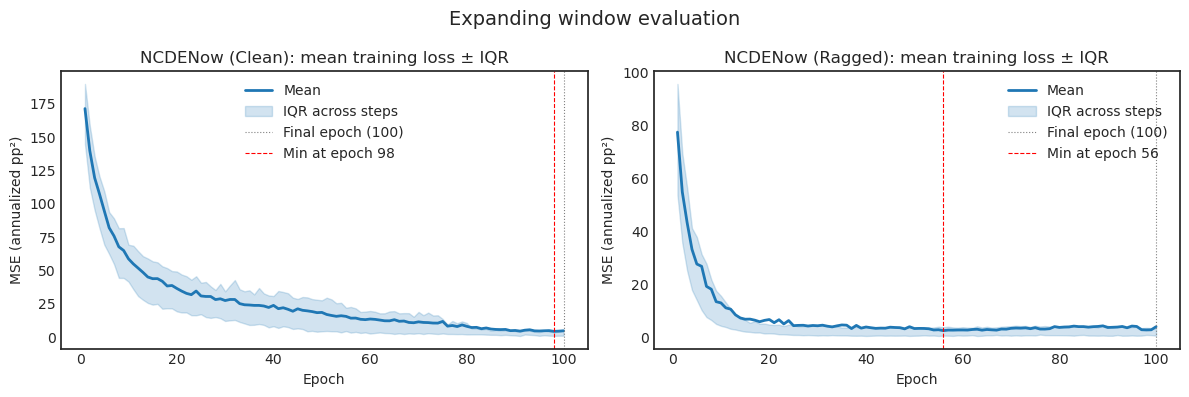

In [34]:
fig_ew_histories, axes = plot_ncde_training_history(
    history_ncde_clean,
    history_ncde_ragged,
    title='Expanding window evaluation'
)
fig_ew_histories.tight_layout()
fig_ew_histories.savefig(
    PLOTS_DIR / 'training_history_expanding_window.png',
    dpi=150
)
plt.show()

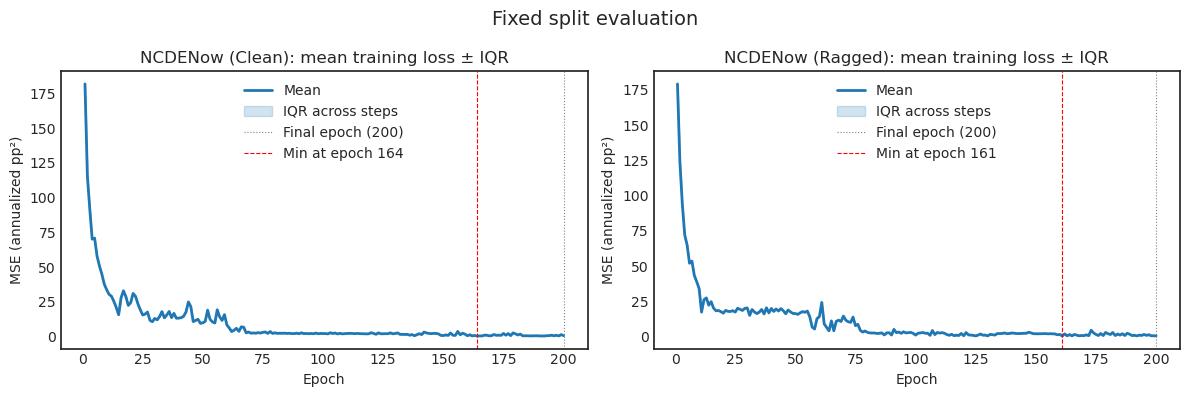

In [35]:
fig_fixed_histories, axes = plot_ncde_training_history(
    history_ncde_clean_fixed,
    history_ncde_ragged_fixed,
    title='Fixed split evaluation'
)
fig_fixed_histories.tight_layout()
fig_fixed_histories.savefig(
    PLOTS_DIR / 'training_history_fixed_split.png',
    dpi=150
)
plt.show()

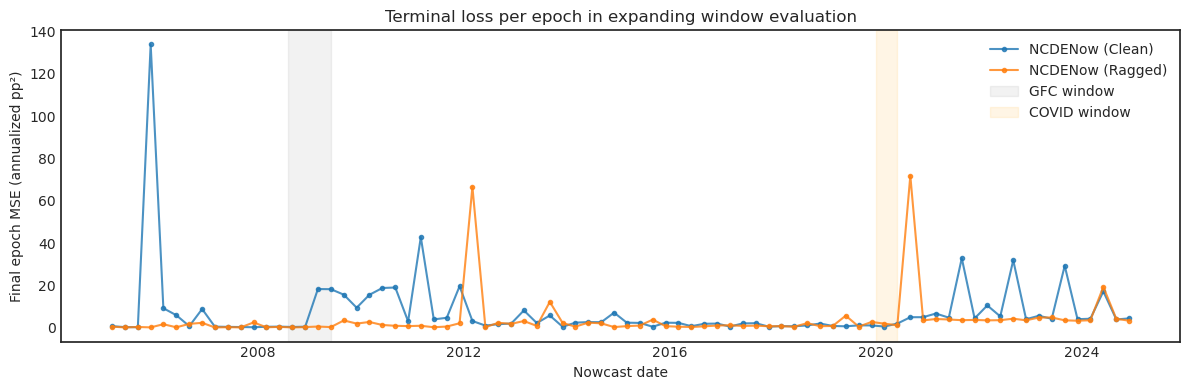

In [36]:
fig_terminal_loss, ax = plot_terminal_loss(
    history_ncde_clean,
    history_ncde_ragged,
    title='Terminal loss per epoch in expanding window evaluation'
)
fig_terminal_loss.tight_layout()
fig_terminal_loss.savefig(
    PLOTS_DIR / 'training_terminal_loss.png',
    dpi=150
)
plt.show()

### 9.2 Model comparisons

In [37]:
def filter_to_test(df, test_start=pd.Timestamp('2019-02-28')):
    return df[df['nowcast_date'] >= test_start].reset_index(drop=True)

# Expanding window.
ew_results = {
    'Ridge': results_ridge,
    'Random Forest': results_rf,
    'NCDENow (clean)': results_ncde_clean,
    'NCDENow (ragged)': results_ncde_ragged
}
ew_table = build_comparison_table(ew_results)

# Fixed split.
fixed_results = {
    'Ridge': filter_to_test(results_ridge),
    'Random Forest': filter_to_test(results_rf),
    'NCDENow (clean)': results_ncde_clean_fixed,
    'NCDENow (ragged)': results_ncde_ragged_fixed
}
fixed_table = build_comparison_table(fixed_results)

In [38]:
ew_table.head()

,n,RMSE,MAE,MDA,RMSE_GFC,n_GFC,RMSE_COVID,n_COVID
Model,,,,,,,,
Ridge,80,7.677495,2.573515,0.8750,3.178783,4,41.446148,2
Random Forest,80,5.664078,2.318191,0.8750,5.037029,4,25.868679,2
NCDENow (clean),80,8.796290,4.424705,0.8125,12.146659,4,37.809438,2
NCDENow (ragged),80,6.595414,3.569196,0.7250,5.015400,4,31.194600,2


In [39]:
fixed_table.head()

,n,RMSE,MAE,MDA,RMSE_GFC,n_GFC,RMSE_COVID,n_COVID
Model,,,,,,,,
Ridge,24,13.752811,5.497597,0.833333,NaN,0,41.446148,2
Random Forest,24,9.883849,4.441221,0.833333,NaN,0,25.868679,2
NCDENow (clean),24,8.141386,4.241767,0.916667,NaN,0,17.452478,2
NCDENow (ragged),24,5.652429,3.846465,0.750000,NaN,0,10.447378,2


In [40]:
def non_covid_window(df):
    covid_start = pd.Timestamp('2020-02-29')
    covid_end   = pd.Timestamp('2020-05-31')
    mask = ~((df['nowcast_date'] >= covid_start) & 
             (df['nowcast_date'] <= covid_end))
    return df[mask].reset_index(drop=True)

# Compare non-COVID performance.
# Expanding window-evaluated models.
print("Expanding window models")
print("=======================")
for label, df in ew_results.items():
    sub = non_covid_window(filter_to_test(df))
    m   = compute_metrics(sub)
    print(f"{label:<30} non-COVID RMSE={m['rmse']:.4f}  n={m['n']}")

# Fixed split-evaluated models.
print("\nFixed split models")
print("==================")
for label, df in fixed_results.items():
    sub = non_covid_window(filter_to_test(df))
    m   = compute_metrics(sub)
    print(f"{label:<30} non-COVID RMSE={m['rmse']:.4f}  n={m['n']}")

Expanding window models
Ridge                          non-COVID RMSE=7.0832  n=22
Random Forest                  non-COVID RMSE=6.7628  n=22
NCDENow (clean)                non-COVID RMSE=8.3553  n=22
NCDENow (ragged)               non-COVID RMSE=5.9049  n=22

Fixed split models
Ridge                          non-COVID RMSE=7.0832  n=22
Random Forest                  non-COVID RMSE=6.7628  n=22
NCDENow (clean)                non-COVID RMSE=6.6797  n=22
NCDENow (ragged)               non-COVID RMSE=4.9932  n=22


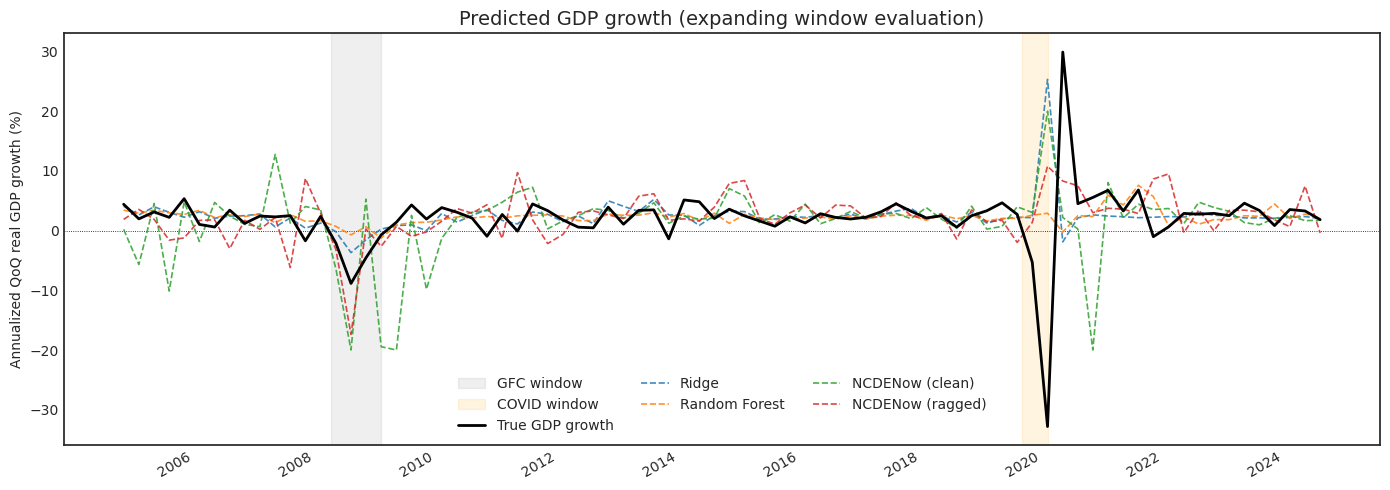

In [41]:
fig_preds_ew, ax = plot_predictions(
    ew_results,
    title='Predicted GDP growth (expanding window evaluation)'
)
fig_preds_ew.tight_layout()
fig_preds_ew.savefig(
    PLOTS_DIR / 'predicted_gdp_expanding_window.png',
    dpi=150
)

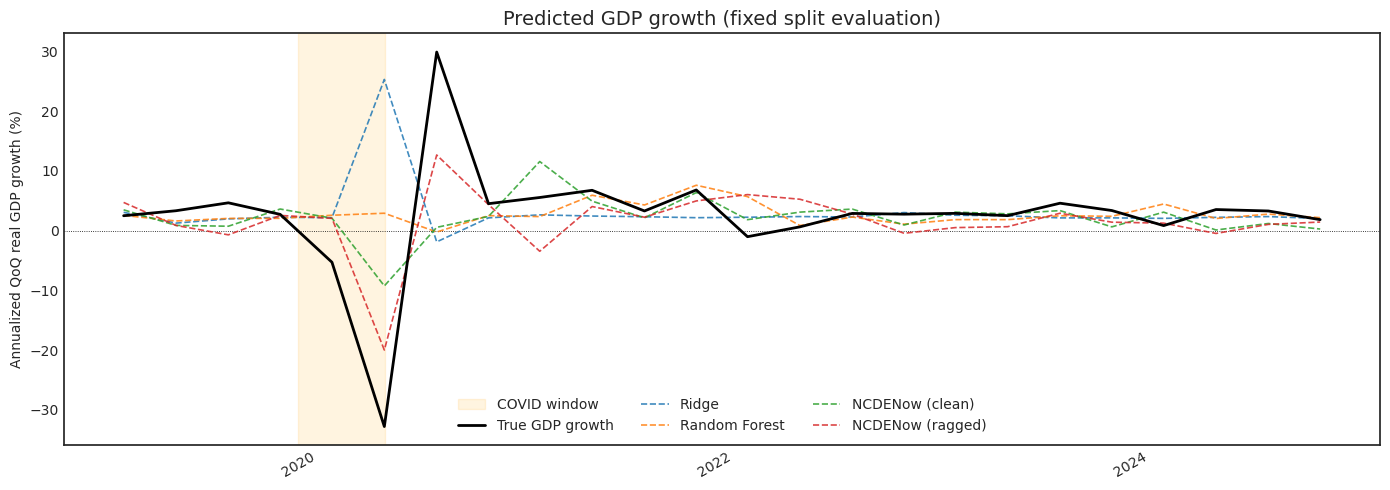

In [42]:
fig_preds_fixed, ax = plot_predictions(
    fixed_results,
    title='Predicted GDP growth (fixed split evaluation)'
)
fig_preds_fixed.tight_layout()
fig_preds_fixed.savefig(
    PLOTS_DIR / 'predicted_gdp_fixed_split.png',
    dpi=150
)